<h1>Exercice 1 - Health Expextation</h1>


-> <a href="https://www.machinelearnia.com/school/course/introduction-data-science/lecture/4990758">Lien vers l'énoncé</a>

-> <a href="https://www.machinelearnia.com/school/course/introduction-data-science/lecture/5057896">Lien vers la correction</a>

<h2>Setup</h2>

In [2]:
# Standard libraries 
import pandas as pd

# Visualisation library
import seaborn as sns
import matplotlib.pyplot as plt



<h2>Data</h2>

In [3]:
# Load data into a DataFrame
df = sns.load_dataset("healthexp")

# Display the 5first rows
df.head()

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9


[ Warning ] : 

Si on travaille sur MacOS et qu'on à ce message d'erreur au chargement des données :
"URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1129)>"

Alors faire : 
"""
If you're using macOS go to Macintosh HD > Applications > Python3.6 folder (or whatever version of python you're using) > double click on "Install Certificates.command" file
"""

Ou faire : 
Supprimer l'environnement actuel avec Python 3.9 et créer un nouvel environnement virtuel avec `uv init --python 3.11` (et si nécessaire `uv venv --python 3.11`)

<h3>Astuces</h3>

In [4]:
# Quick visualisation of our data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             274 non-null    int64  
 1   Country          274 non-null    str    
 2   Spending_USD     274 non-null    float64
 3   Life_Expectancy  274 non-null    float64
dtypes: float64(2), int64(1), str(1)
memory usage: 8.7 KB


On peut ainsi voir le nombre de lignes (`274 entries, 0 to 273 `) le nombre de colonnes (`total 5 columns`).  On a ensuite un détail sur ces différentes colonnes avec le nombre de valeurs `non-null` et le type de la variable (`int`, `object` comme des \[`str, etc`\], `float`. 
Enfin, cette méthode nous indique également quelle place tout ce DataFrame prend sur notre RAM.

Beaucoup de monde connait cette fonction mais peu de personne l'utilise. Pourtant, c'est un super point de départ. 

Une seconde astuce est d'utiliser la méthode `nunique()` de Pandas. Comme on peut le voir ci-dessous, cela va indiquer le nombre de valeurs unique qu'on va retrouver dans chaque colonne. 

In [ ]:
# Count the number of unique value in each column
df.nunique()

Year                51
Country              6
Spending_USD       274
Life_Expectancy    118
dtype: int64

Ici par exemple, on a 6 valeurs unique pour la colonne `Country`.  Cela peut nous aider à déterminer qu'est-ce qui est considéré comme une variable discrète et qu'est ce qui est considéré comme une variable continue. 

Il faut donc retenir ces deux fonctions `nunique()` et `info()`, et les utiliser. !!! 

<h2>Questions et réponses</h2>

<h3>1. <u>Déterminez quelles sont les variables Discrètes et Continues du dataset</u></h3>

Variables discrètes : `Year` et `Country` 

Variables continues : `Spending_USD` et `Life_Expectancy`

<h3>2. <u>Analysez la variable "Country".</u></h3>

...

In [7]:
# Count the number of individuous within each category
df["Country"].value_counts()

Country
Japan            51
USA              51
Germany          50
Canada           44
Great Britain    43
France           35
Name: count, dtype: int64

<Axes: xlabel='Country'>

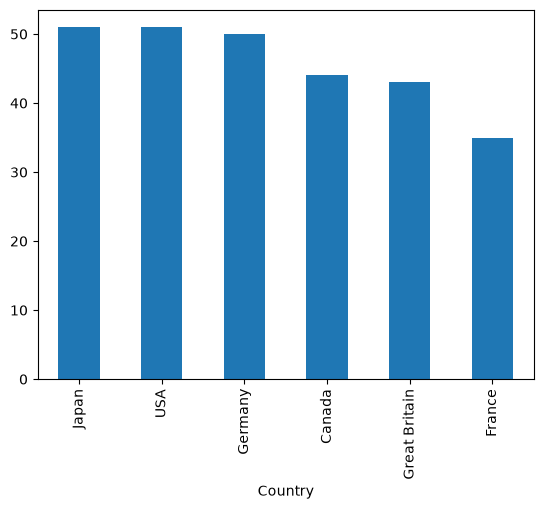

In [8]:
# Dispay those numbers within a chart 
df["Country"].value_counts().plot(kind="bar")

<h3>3. <u>Analysez la variable "Spending_USD"</u></h3>

- Formulez dans une phrase claire ce que signifie la moyenne issue de cette analyse (Attention, soyez vraiment précis, c'est important)

- Réalisez les 2 graphiques utiles pour cette analyse



Ici `Spending_USD` est une variable continue, pour l'étudier on va faire une analyse univariée en cherchant à calculer des statistiques telles que : la moyenne, la médiane, la variance, l'écart-type, ...Pour cela, la fonction describe s'occupe déjà de tout.

In [11]:
# Compute `Spending_USD` variable statistics
df["Spending_USD"].describe()

count      274.000000
mean      2789.338905
std       2194.939785
min        123.993000
25%       1038.357000
50%       2295.578000
75%       4055.610000
max      11859.179000
Name: Spending_USD, dtype: float64

Tout pays confondus, la dépense moyenne en USD est de 2789.

Attention, cette valeur est à mettre en perspective car en voyant l'écart-type, on constate que la distribution est un peu étalée : str = 2194. 

On pourrait chercher à vouloir calculer les statistiques de ces dépenses par pays. 

In [14]:
df.groupby("Country")["Spending_USD"].describe()

,count,mean,std,min,25%,50%,75%,max
Country,,,,,,,,
Canada,44.0,2685.778341,1526.252453,313.391,1435.33825,2239.361,3998.28700,5828.324
France,35.0,3045.145057,1468.282187,192.143,1958.98000,3152.016,4230.56600,5468.418
Germany,50.0,2667.280200,1873.356162,252.311,1059.54450,2414.681,3904.04875,6938.983
Great Britain,43.0,2034.192465,1433.797586,123.993,713.88150,1683.905,3388.10800,5018.700
Japan,51.0,1860.257902,1467.225806,150.437,689.81700,1420.271,2744.55700,4665.641
USA,51.0,4388.570529,3386.309322,326.961,1390.80700,3586.745,7275.76950,11859.179


De cette manière, on observe la dépense moyenne en USD propre à chaque pays. 

<Axes: xlabel='Country'>

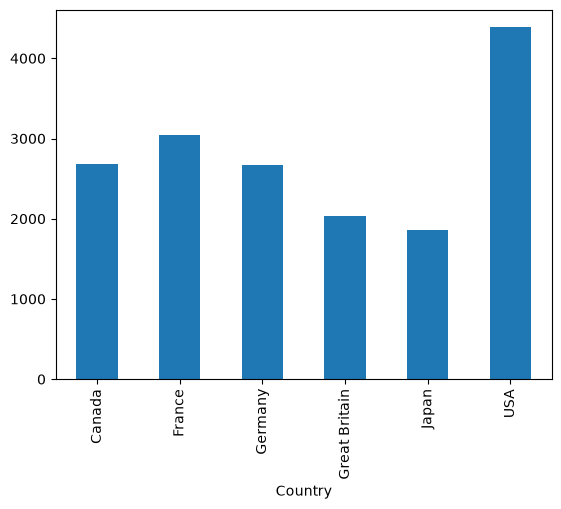

In [38]:
# Display the total mean USD spent by country over the full period
df.groupby("Country")["Spending_USD"].mean().plot(kind="bar")

On constate ques les USA ont dépensé en moyenne le double, voire le triple, en valeur d'USD que les autres pays. Les dépenses des autres pays tournent autour de 2000 en moyenne. 

<Axes: >

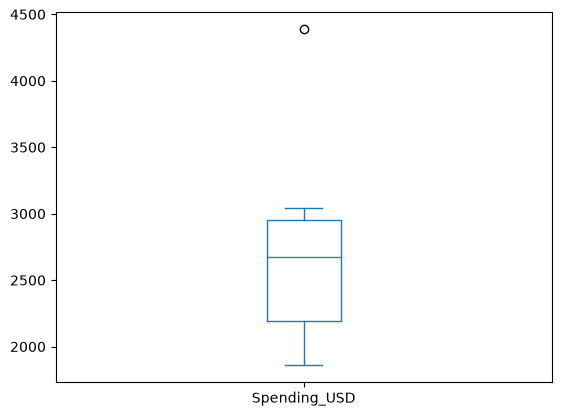

In [39]:
# Display the total mean USD spent by country over the full period with
df.groupby("Country")["Spending_USD"].mean().plot(kind="bar")

En effet, on constate donc qu'il y a un outlier, qui sont les États-Unis et qui viennnet gonfler la moyenne alors que les autres pays dépenses beaucoup moins. 

Si on devait faire du feature engineering, une valeur intéressante à construire serait de calculer le rapport des dépenses d'un pays par rapport à la taille de sa population. Peut-être que ces dépenses ne seraient pas si éloignées que ça au final. 

<Axes: title={'center': 'Spending_USD'}, xlabel='Country'>

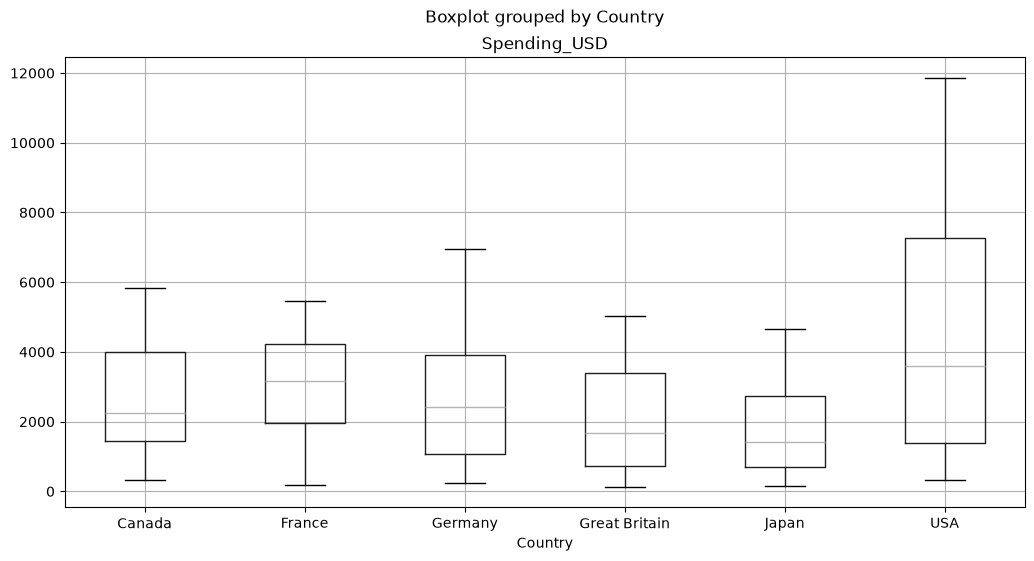

In [52]:
# Display the boxplot for each country
df.boxplot(column="Spending_USD", by="Country", figsize=(12, 6))

Ainsi, on remarque que les distribution des dépenses en USD pour chaque pays sur l'ensemble de la période sont du même ordre de grandeur, à l'exception des USA qui présentent des valeurs bien plus importantes.

Maintenant, on pourrait voiloir générer une courbe par pays pour avoir le montant qu'il dépense chaque décénnies. Pour cela, on peut calculer la moyenne des dépenses de ces pays par intervalle de 10 ans. 

<Axes: xlabel='Decade'>

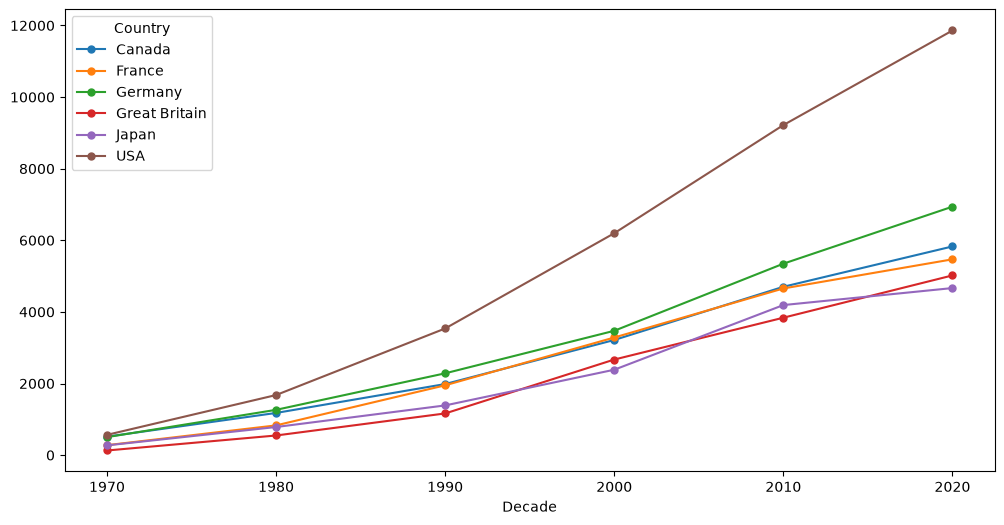

In [29]:
# Create a decade column 
df["Decade"] = (df["Year"] // 10) * 10

# Display the USD spent by country by decade
df.groupby(["Decade", "Country"])['Spending_USD'].mean().unstack().plot(figsize=(12, 6), marker="o", markersize=5)


De cette manière, on se rend compte que non seulement les dépenses en USD de chaque pays ont tendance à augmenter chaqeu décénnie, mais en plus que les dépenses des USA sont bien supérieures à celles des autres pays (environ x3). 

Attention, il faut aussi relativiser ces information. Il faut voir combien coûte les soin dans chaque pays, combien de personnes cela concerne, etc. D'autres paramètres sont à prendre en compte. On ne peut pas tirer des conclusions hâtives.

<h3>4. <u>Faire de même pour la variable "Life_Expectancy"</u></h3>

De la même manière, la variable `Life_Expectancy` est une variable continue, on va donc procéder de la même manière qu'avec `Spending_USD`

In [41]:
df["Life_Expectancy"].describe()

count    274.000000
mean      77.909489
std        3.276263
min       70.600000
25%       75.525000
50%       78.100000
75%       80.575000
max       84.700000
Name: Life_Expectancy, dtype: float64

Ainsi, on observe que l'espérance de vie moyen, tout pays confondu est d'environ 77,9 ans. 

Une fois encore, peut-être que la moyenne d'age de certain pays est plus ou moins élevée par rapport à un autre. On va donc chercher à ventiler cela. 

<Axes: xlabel='Country'>

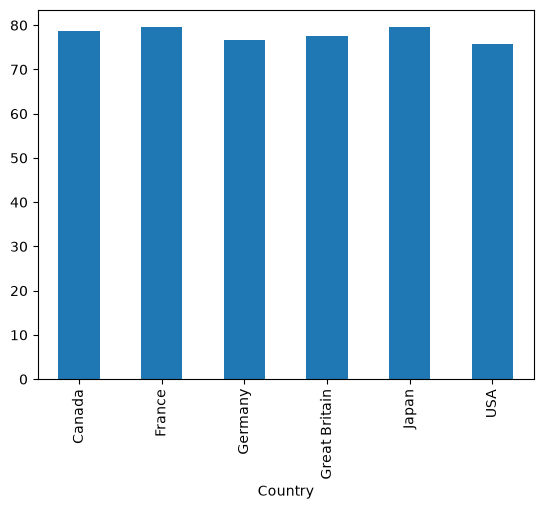

In [54]:
# Compute the `Life_Expectancy` stat by country and display their mean
df.groupby("Country")["Life_Expectancy"].mean().plot(kind="bar")

La moyenne d'age est relativement équivalente pour chaque pays du dataset.

<Axes: title={'center': 'Life_Expectancy'}, xlabel='Country'>

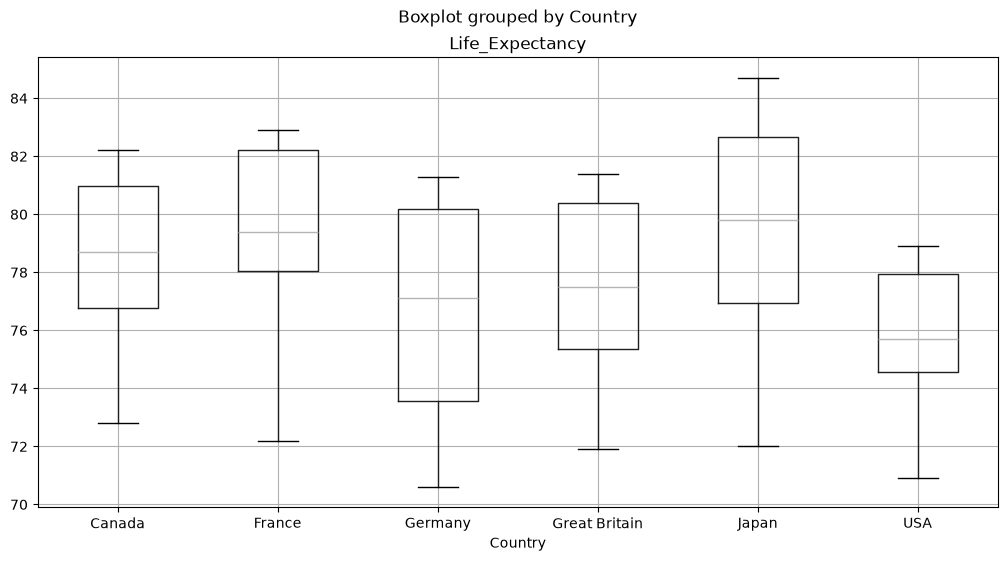

In [53]:
# Display more details for each stat through boxplots 
df.boxplot(column="Life_Expectancy", by="Country", figsize=(12, 6))

Enfin, on pourrait vouloir observer commenet l'age évolue à travers les années pour chaque pays. 

<Axes: xlabel='Year'>

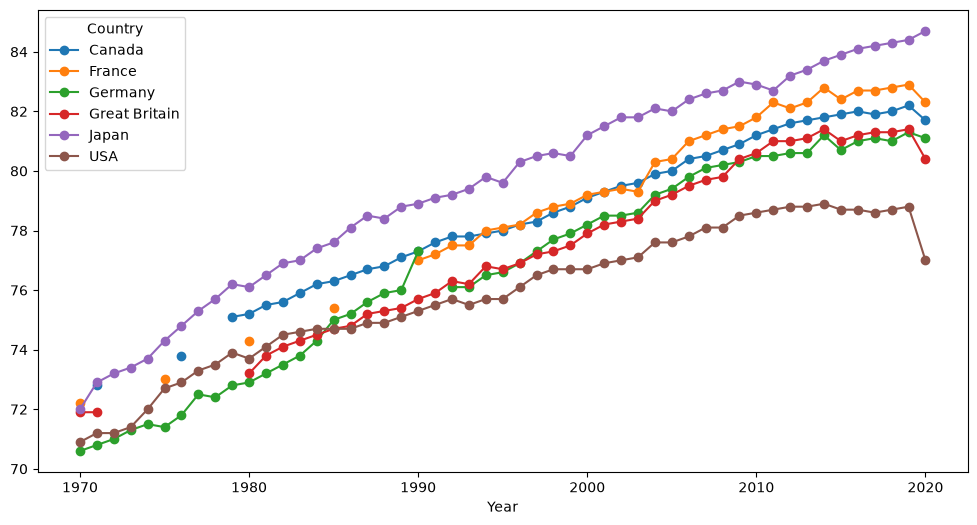

In [62]:
df.pivot(index="Year", columns="Country", values="Life_Expectancy").plot(figsize=(12, 6), marker="o")

Ainsi, on observe que depuis 1970, la moyenne d'age n'a fait qu'augmenter pour chaque pays, même si elle croit de manière plus ou moins constante selon les pays. En effet, si on regarde le japon, on constate que la moyenne d'âge est constamment au dessus des autres pays. On peut donc en conclure que le Japon disposes d'outils, d'une méthode, d'une hygiène de vie ou d'une culture qui permet de vivre plus longtemps que les autres pays. 

<h3>5. <u>Observez l'évolution de la durée de vie à travers le temps.</u></h3>

Bon ba déjà fait ! Mais on peut le faire de manière globale

<Axes: xlabel='Year'>

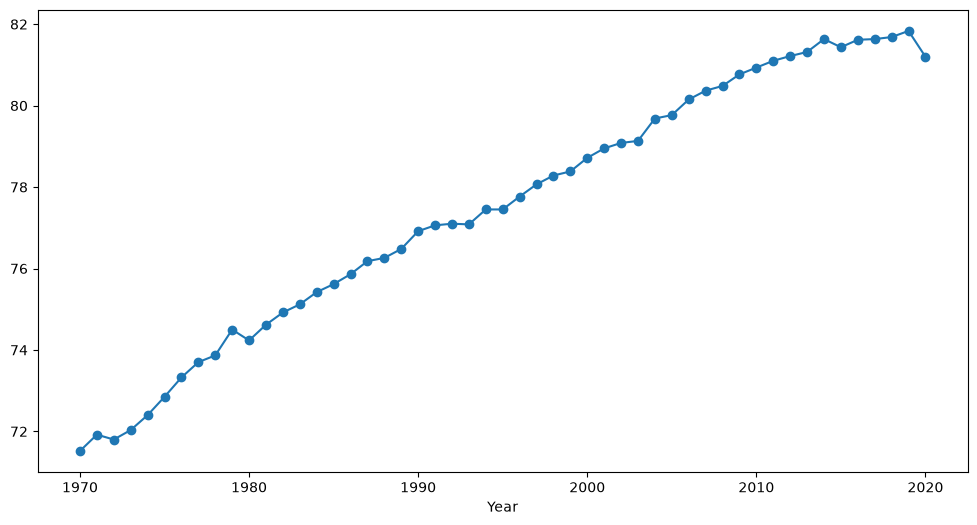

In [64]:
df.groupby("Year")["Life_Expectancy"].mean().plot(figsize=(12, 6), 
marker="o")

<h3>6. <u>Oups... Comment améliorer ce graphique ?</u></h3>

I don't know

<h3>7. <u>Observez l'évolution des dépenses en santé de l'Allemagne et de la Grande Bretagne à travers le temps.</u></h3>

Déjà fait avec tous les pays mais on peut le refaire juste pour ces deux pays 

<Axes: xlabel='Year'>

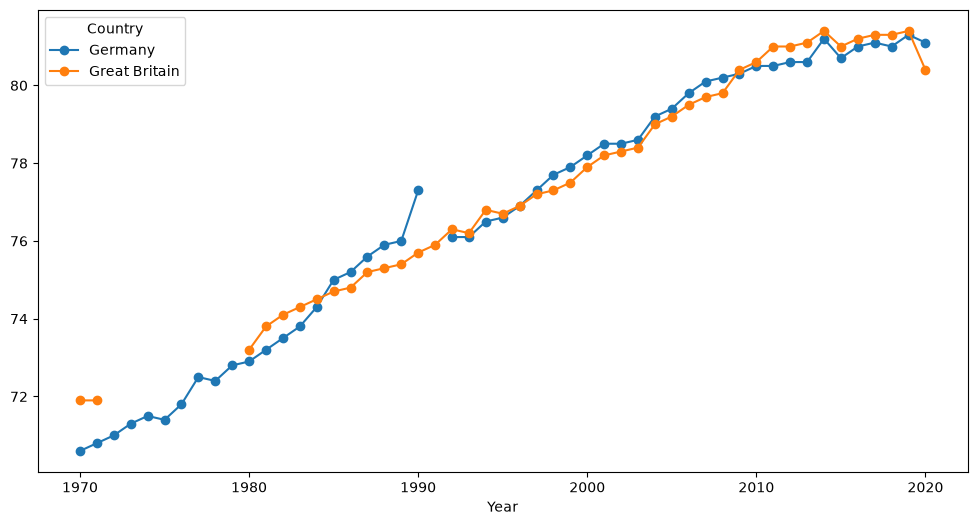

In [68]:
df[df["Country"].isin(["Great Britain", "Germany"])].pivot(index="Year", columns="Country", values="Life_Expectancy").plot(figsize=(12, 6), marker="o")

On constate qu'à travers les années, les dépenses en santé de l'Allemagne et de la grande bretagne sont équivalentes. 

<h3>8. <u>Observez l'histograme, la boxplot, et les statistiques de "Life_Expectancy" propre à chaque pays.</u></h3>

Déjà fait ! 

<h3>9. <u>Observez la relation entre la durée de vie et les dépenses dans la santé, aux États-Unis, de 2000 à 2020</u></h3>

Comme on a pu le mentionner précédemment, les variables `Life_Expectancy` et `Spending_USD` sont des variables continues. Par conséquent, si on souhaite réaliser une analyse multivariée sur ces variables il suffit d'afficher une variable en fonction de l'autre dans un nuage de points `scatter plot`. 

<Axes: xlabel='Spending_USD', ylabel='Life_Expectancy'>

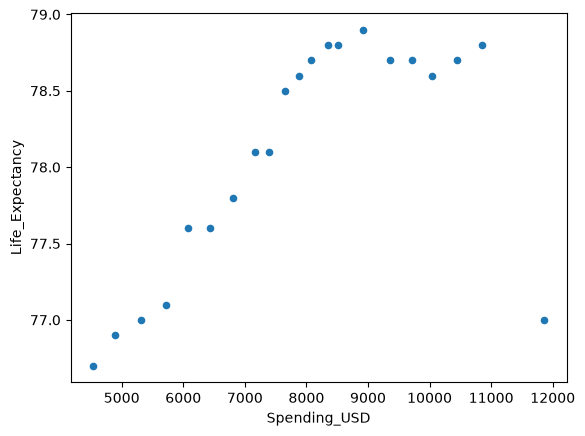

In [78]:
df[(df["Country"] == "USA") & (df["Year"]>=2000)].plot.scatter(x="Spending_USD", y="Life_Expectancy")

Entre 2000 et 2020, on constate que de 0 USD jusqu'à 9000 USD investis, on peut retrouver une relation preque linéaire. De manière à ce que plus on investi et plus la population vis longtemps. Cependant, les investissement au delà de 9000 USD, ne sont plus corrélée avec la durée de vie. Ce qui signifie qu'au delà de 79 ans, les investissement en santé de suffisent pas pour permettre a la population de vivre plus longtemps. 

Comme toujours, ces valeurs sont à mettre en perspective avec le conxte poitico-économique, l'hygiène de vie, les crises sanitaires, les prédispositions génétiques de chacun. Etc 

<h3>10. <u>Il y a une valeur aberrante tant tout cela. Laquelle? Pourquoi?</u></h3>